# Exploratory Data Analysis (EDA)

### Objective

Understand dataset structure, quality, labels and text characteristics.

#### Download data

In [2]:
import requests
import pandas as pd

url = "https://mock-redcap-service.onrender.com/api/nlp/responses"

data = requests.get(url).json()

df = pd.DataFrame(data["data"])

#### Save raw data

In [3]:
df.to_csv("C:/Users/yasmine/Documents/neps/neps-ml-ai/data/raw/nlp_responses.csv", index=False)

#### Load data

In [4]:
import pandas as pd

df = pd.read_csv("C:/Users/yasmine/Documents/neps/neps-ml-ai/data/raw/nlp_responses.csv")

#### Dataset overview

In [5]:
df.shape

(2000, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   participant_id     2000 non-null   object 
 1   response_id        2000 non-null   object 
 2   response_type      2000 non-null   object 
 3   collection_date    2000 non-null   object 
 4   month              2000 non-null   object 
 5   country            2000 non-null   object 
 6   site               2000 non-null   object 
 7   question_prompt    2000 non-null   object 
 8   response_text      2000 non-null   object 
 9   word_count         2000 non-null   int64  
 10  language           2000 non-null   object 
 11  severity_level     2000 non-null   object 
 12  anxiety_level      2000 non-null   object 
 13  depression_level   2000 non-null   object 
 14  stress_level       2000 non-null   object 
 15  emotional_label    2000 non-null   object 
 16  clinical_status    2000 

In [7]:
df.head()

,participant_id,response_id,response_type,collection_date,month,country,site,question_prompt,response_text,word_count,...,depression_level,stress_level,emotional_label,clinical_status,sentiment_score,sentiment_manual,suicidality_flag,requires_referral,alert_priority,thematic_codes
0,NEPS-TZA-0195,NLP-29B24D86,interview_transcript,2026-02-20,February,TZA,Fourah_Bay,Describe a recent difficult experience,I've been thinking a lot about my future latel...,40,...,low,low,confusion,mild_distress,-0.07,neutral,no,no,p2,['future_anxiety']
1,NEPS-SLE-0022,NLP-93DCB44A,interview_transcript,2026-01-20,January,SLE,UDSM,What worries you most about the future?,I had a panic attack in the library and nobody...,31,...,high,moderate,loneliness,depressed,-0.52,negative,no,yes,p1,['social_isolation']
2,NEPS-SLE-0241,NLP-0A5A10CF,youth_narrative,2026-04-14,April,SLE,Dar_es_Salaam_Poly,Describe your daily emotional state,I made a budget and stuck to it for two weeks....,34,...,low,low,hope,normal,0.38,mildly_positive,no,no,p2,['general_distress']
3,NEPS-GHA-0169,NLP-09C2B9FA,youth_narrative,2026-05-02,May,GHA,Bo_Campus,How do you cope with stress?,My professor stayed after class to explain the...,37,...,low,low,gratitude,normal,0.71,positive,no,no,p2,['academic_pressure']
4,NEPS-GHA-0162,NLP-FBBA6A89,open_ended,2026-04-23,April,GHA,UDSM,What would you change about your life?,I got good news and bad news on the same day a...,32,...,high,low,numbness,depressed,-0.54,negative,no,yes,p1,['general_distress']


In [8]:
df.isnull().sum()

participant_id       0
response_id          0
response_type        0
collection_date      0
month                0
country              0
site                 0
question_prompt      0
response_text        0
word_count           0
language             0
severity_level       0
anxiety_level        0
depression_level     0
stress_level         0
emotional_label      0
clinical_status      0
sentiment_score      0
sentiment_manual     0
suicidality_flag     0
requires_referral    0
alert_priority       0
thematic_codes       0
dtype: int64

#### Sentiment distribution

In [9]:
df["sentiment_manual"].value_counts()

sentiment_manual
negative           1000
mildly_negative     300
positive            280
mildly_positive     220
neutral             200
Name: count, dtype: int64

<Axes: xlabel='sentiment_manual'>

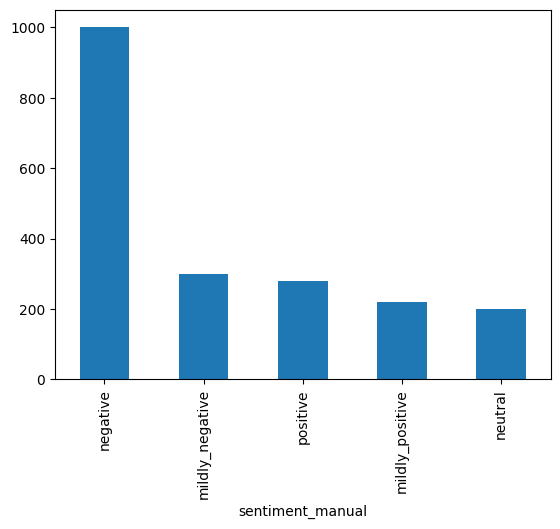

In [10]:
df["sentiment_manual"].value_counts().plot(
    kind="bar"
)

#### Emotion distribution

In [11]:
df['emotional_label'].value_counts()

emotional_label
confusion         200
despair           186
hope              163
contentment       128
emptiness         120
anger             118
disappointment    114
fear              105
shame             105
numbness           95
frustration        95
loneliness         93
worry              91
sadness            90
guilt              88
pride              46
love               45
gratitude          35
joy                31
confidence         28
calm               24
Name: count, dtype: int64

<Axes: xlabel='emotional_label'>

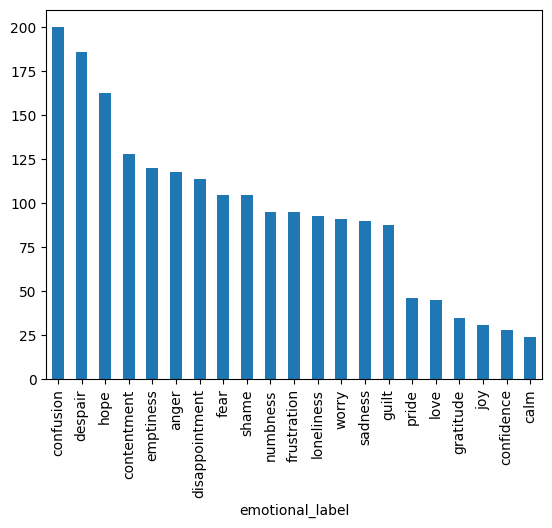

In [12]:
df['emotional_label'].value_counts().plot(
    kind='bar'
)

#### Severity distribution

In [13]:
df['severity_level'].value_counts()

severity_level
high        1000
low          700
moderate     300
Name: count, dtype: int64

<Axes: xlabel='severity_level'>

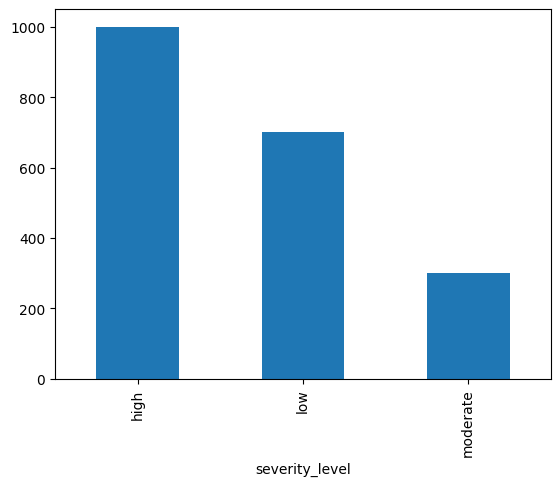

In [14]:
df['severity_level'].value_counts().plot(
    kind='bar'
)

#### Theme distribution

In [15]:
from collections import Counter
import ast

themes = Counter()

for row in df["thematic_codes"]:
    themes.update(ast.literal_eval(row))

themes

Counter({'general_distress': 645,
         'academic_pressure': 391,
         'social_isolation': 360,
         'family_conflict': 264,
         'health_concerns': 249,
         'future_anxiety': 231,
         'relationship_issues': 212,
         'financial_stress': 139,
         'self_harm_risk': 79,
         'social_media_pressure': 53,
         'identity_crisis': 43,
         'grief_loss': 42,
         'trauma': 22,
         'discrimination': 21,
         'bullying': 20,
         'spiritual_crisis': 5})

<Axes: xlabel='theme'>

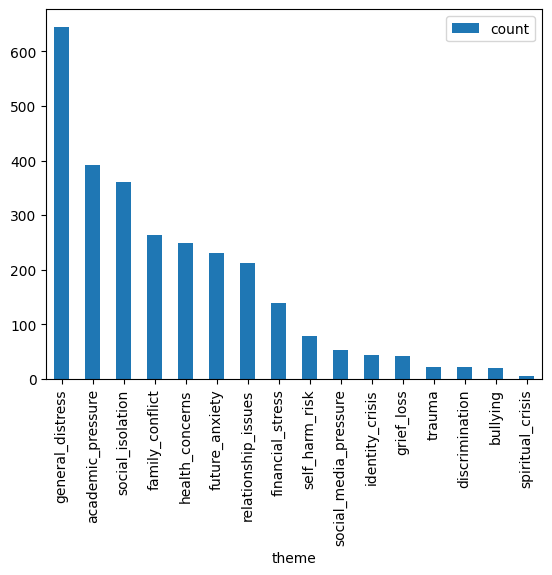

In [16]:
import pandas as pd

theme_df = pd.DataFrame(
    themes.items(),
    columns=["theme","count"]
)

theme_df.sort_values(
    "count",
    ascending=False
).plot.bar(
    x="theme",
    y="count"
)

#### Narrative length analysis

<Axes: xlabel='sentiment_manual', ylabel='word_count'>

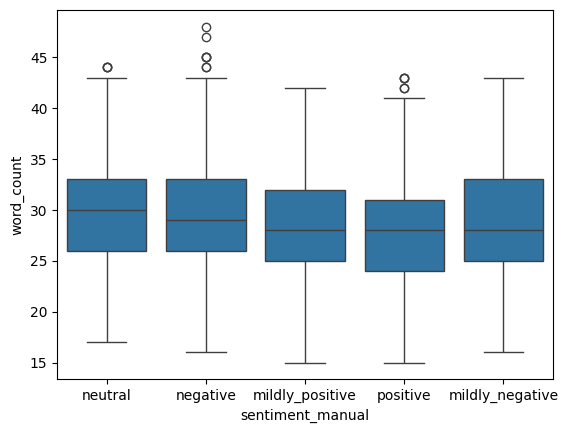

In [17]:
import seaborn as sns

sns.boxplot(
    x="sentiment_manual",
    y="word_count",
    data=df
)

#### Most frequent words

In [18]:
from collections import Counter

all_words = " ".join(
    df["response_text"]
).lower().split()

Counter(all_words).most_common(50)

[('i', 4221),
 ('my', 2124),
 ('the', 2070),
 ('to', 1612),
 ('but', 1289),
 ('and', 1250),
 ('a', 946),
 ("don't", 835),
 ('is', 829),
 ("it's", 827),
 ("i'm", 826),
 ('me', 626),
 ('it', 543),
 ('of', 529),
 ('this', 525),
 ('have', 504),
 ('for', 468),
 ('know', 450),
 ('with', 443),
 ('been', 404),
 ('about', 403),
 ('on', 344),
 ('what', 334),
 ('feel', 321),
 ("can't", 313),
 ("i've", 308),
 ('was', 302),
 ('not', 292),
 ('like', 266),
 ('in', 265),
 ('that', 260),
 ('has', 253),
 ('now', 229),
 ('at', 225),
 ('it.', 223),
 ('from', 221),
 ('out', 218),
 ('going', 200),
 ('getting', 198),
 ('semester.', 196),
 ('just', 189),
 ('because', 187),
 ('things', 186),
 ('up', 184),
 ('felt', 182),
 ('myself', 176),
 ('me.', 175),
 ('this.', 173),
 ('be', 173),
 ('nobody', 161)]

#### Word cloud

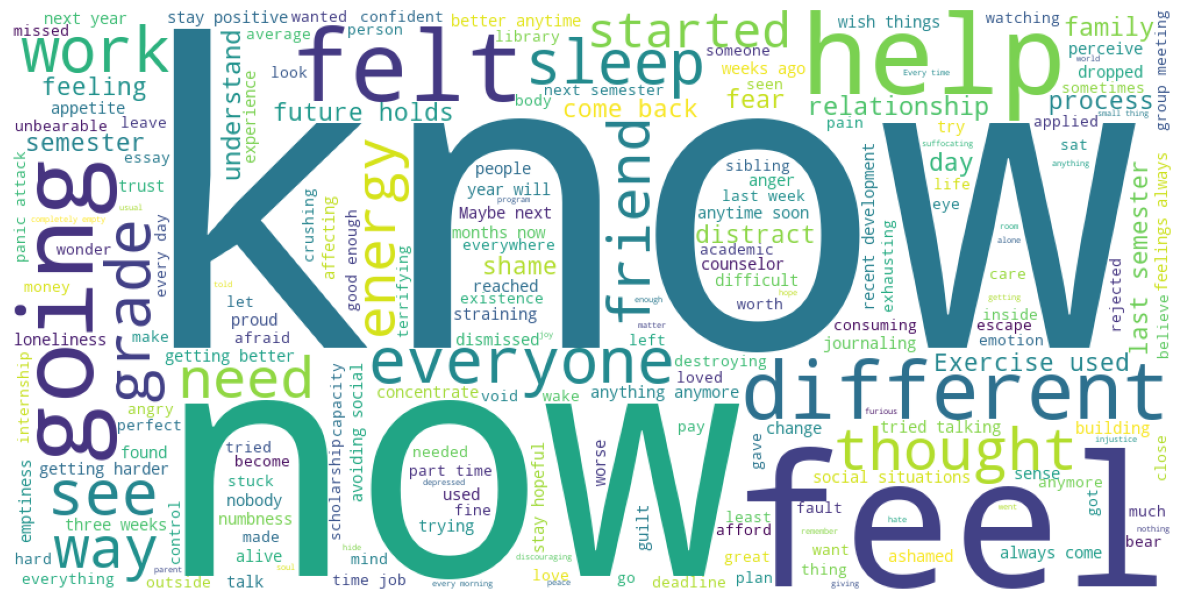

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(
    df["response_text"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

#### Word cloud by sentiment

##### Negative narratives

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

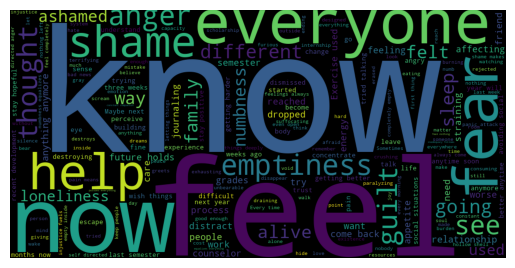

In [20]:
negative_text = " ".join(
    df[df["sentiment_manual"]=="negative"]
    ["response_text"]
)

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(negative_text)

plt.imshow(wordcloud)

plt.axis("off")

##### Positive narratives

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

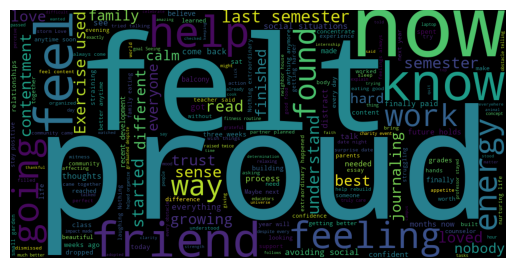

In [21]:
positive_text = " ".join(
    df[df["sentiment_manual"]=="positive"]
    ["response_text"]
)

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(positive_text)

plt.imshow(wordcloud)

plt.axis("off")

#### N-gram analysis

##### Bi-grams

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X = vectorizer.fit_transform(
    df["response_text"]
)

sum_words = X.sum(axis=0)

##### Top bigrams

In [23]:
words_freq = [

    (word, sum_words[0, idx])

    for word, idx

    in vectorizer.vocabulary_.items()

]

sorted(
    words_freq,
    key=lambda x: x[1],
    reverse=True
)[:20]

[('don know', np.int64(380)),
 ('help don', np.int64(102)),
 ('know future', np.int64(102)),
 ('future holds', np.int64(102)),
 ('exercise used', np.int64(101)),
 ('used help', np.int64(101)),
 ('don energy', np.int64(101)),
 ('getting better', np.int64(99)),
 ('distract work', np.int64(97)),
 ('work feelings', np.int64(97)),
 ('feel like', np.int64(97)),
 ('ve felt', np.int64(96)),
 ('friends don', np.int64(95)),
 ('didn help', np.int64(91)),
 ('affecting sleep', np.int64(91)),
 ('going months', np.int64(89)),
 ('felt way', np.int64(87)),
 ('way semester', np.int64(87)),
 ('don understand', np.int64(86)),
 ('understand going', np.int64(86))]

#### Sentiment-specific keywords

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000
)

X = tfidf.fit_transform(
    df["response_text"]
)


print(tfidf.get_feature_names_out()[:100])

['abandonment' 'about' 'abroad' 'absolute' 'absolutely' 'academic'
 'academics' 'accident' 'ache' 'action' 'actually' 'adequate'
 'administration' 'advisor' 'affecting' 'afford' 'afraid' 'after' 'again'
 'against' 'ago' 'alcohol' 'alive' 'all' 'alone' 'along' 'already' 'also'
 'always' 'am' 'amazing' 'an' 'and' 'anger' 'angry' 'annoyed' 'annoying'
 'another' 'answered' 'anxiety' 'anxious' 'any' 'anymore' 'anyone'
 'anything' 'anytime' 'anyway' 'apartment' 'appetite' 'applications'
 'applied' 'appreciate' 'are' 'area' 'around' 'as' 'ashamed' 'ask' 'asked'
 'asking' 'asks' 'aspect' 'assignments' 'at' 'ate' 'attack' 'attacks'
 'authenticity' 'average' 'avoid' 'avoiding' 'awake' 'away' 'awful'
 'awkward' 'back' 'background' 'bad' 'balcony' 'barks' 'be' 'bear'
 'beautiful' 'because' 'become' 'bed' 'been' 'before' 'behind' 'being'
 'believe' 'believed' 'belong' 'belonging' 'best' 'betrayal' 'betrayed'
 'better' 'between' 'bigger']
